In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os, json

## Loss Curves

In [4]:

def plot_learning_curves(path, train_loss, test_loss, log_scale):
    #train_loss = np.log10(train_loss) if log_scale else train_loss
    #test_loss = np.log10(test_loss) if log_scale else test_loss
    sns.set_theme()
    plt.figure()
    plt.plot(train_loss, label="Train loss")
    plt.xlabel("Epochs", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Loss", fontsize=13, fontweight='bold', loc="center")
    if log_scale: plt.yscale('log')
    plt.legend(loc="best")
    plt.title("Training loss", fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "training_loss.png"), dpi=150)

    plt.figure()
    plt.plot(test_loss, label="Validation loss", c="orange")
    if log_scale: plt.yscale('log')
    plt.xlabel("Epochs", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Loss", fontsize=13, fontweight='bold', loc="center")
    plt.legend(loc="best")
    plt.title("Test loss", fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "test_loss.png"), dpi=150)

    plt.figure()
    plt.plot(train_loss, label="Train loss")
    plt.plot(test_loss, label="Validation loss")
    if log_scale: plt.yscale('log')
    plt.ylim(top=0.3)
    plt.xlabel("Epochs", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Loss", fontsize=13, fontweight='bold', loc="center")
    plt.legend(loc="best", fontsize=12)
    plt.title("Loss curves", fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "loss_curves.png"))

    # save the data
    with open(os.path.join(path, "train_loss.npy"), "wb") as file:
        np.save(file, train_loss, allow_pickle=True)
    with open(os.path.join(path, "test_loss.npy"), "wb") as file:
        np.save(file, test_loss, allow_pickle=True)

    return

In [5]:
paths_curve = os.path.join(os.getcwd(), "experiments/exp_2025-11-13_08-55-14/curves")
# Load train and test loss
with open(os.path.join(paths_curve, "Train_EpochLoss.json"), "r") as f:
    train_loss = json.load(f)
    train_loss = np.array(train_loss)
# Load train and test loss
with open(os.path.join(paths_curve, "Val_EpochLoss.json"), "r") as f:
    val_loss = json.load(f)
    val_loss = np.array(val_loss)[1:, :]

print(train_loss.shape)
print(val_loss.shape)

(101, 3)
(100, 3)


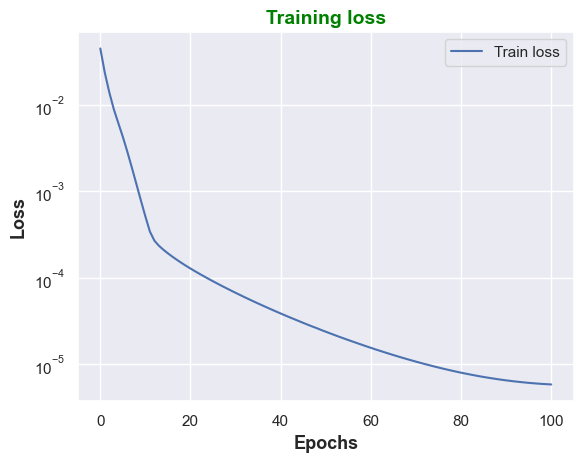

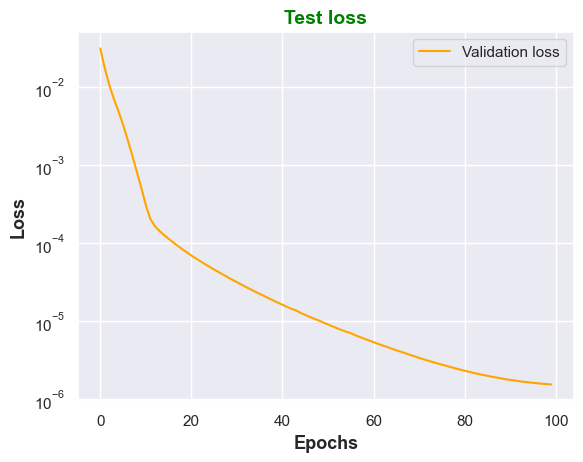

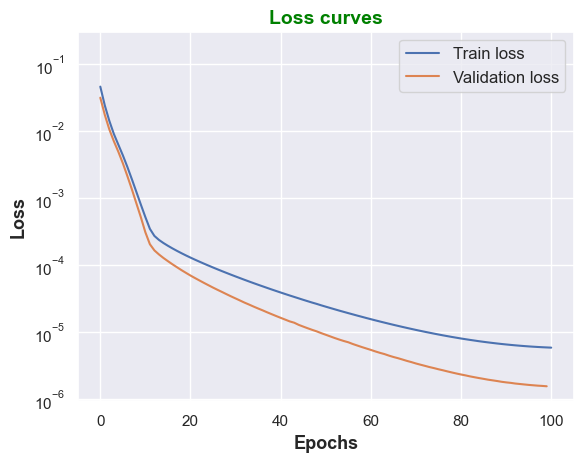

In [6]:
plot_learning_curves(path=paths_curve, train_loss=train_loss[:, -1], test_loss=val_loss[:, -1], log_scale=True)

## Magnitude & Phase Curves

In [7]:
def plot_magnitude(path, curve, label, title, log_scale=True):
    sns.set_theme()
    plt.figure()
    plt.plot(curve, label=label)
    plt.xlabel("Iterations", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Difference", fontsize=13, fontweight='bold', loc="center")
    if log_scale: plt.yscale('log')
    plt.legend(loc="best")
    plt.title(title, fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "training_loss.png"), dpi=150)

def plot_phase(path, curve, label, title, log_scale=True):
    plt.figure()
    plt.plot(curve, label=label, c="orange")
    if log_scale: plt.yscale('log')
    plt.xlabel("Iterations", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Difference", fontsize=13, fontweight='bold', loc="center")
    plt.legend(loc="best")
    plt.title(title, fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "test_loss.png"), dpi=150)


def plot_phase_subplot(path, curve1, curve2, yaxis_1, yaxis_2, 
                       label1, label2, title, log_curve1=True, 
                       log_curve2=True, save_name="fig.png", vertical=False):
    sns.set_theme()
    fig, axes = plt.subplots(2 if vertical else 1, 1 if vertical else 2, figsize=(10, 5))
    axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    # --- Magnitude plot ---
    axes[0].plot(curve1, label=label1, c="orange")
    axes[0].set_xlabel("Epochs", fontsize=12, fontweight='bold')
    axes[0].set_ylabel(yaxis_1, fontsize=12, fontweight='bold')
    if log_curve1:
        axes[0].set_yscale('log')
    axes[0].legend(loc="best", fontsize=12)
    #axes[0].set_title(f"{title} - Magnitude", fontsize=14, c="green", fontweight='bold')

    # --- Phase plot ---
    axes[1].plot(curve2, label=label2, c="orange")
    axes[1].set_xlabel("Epochs", fontsize=12, fontweight='bold')
    axes[1].set_ylabel(yaxis_2, fontsize=12, fontweight='bold')
    if log_curve2:
        axes[1].set_yscale('log')
    axes[1].legend(loc="best", fontsize=12)
    #axes[1].set_title(f"{title}", fontsize=14, c="green", fontweight='bold')
    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(path, save_name), dpi=150)
    #plt.close(fig)


def plot_magnitude_phase(path, train_curve, val_curve, log_scale, train_label="Magnitude"):
    plt.figure()
    plt.plot(train_curve, label="Train loss")
    plt.plot(val_curve, label="Validation loss")
    if log_scale: plt.yscale('log')
    plt.ylim(top=0.3)
    plt.xlabel("Epochs", fontsize=13, fontweight='bold', loc="center")
    plt.ylabel("Loss", fontsize=13, fontweight='bold', loc="center")
    plt.legend(loc="best")
    plt.title("Loss curves", fontsize=14, c="green", fontweight='bold')
    plt.savefig(os.path.join(path, "loss_curves.png"))

    # save the data
    with open(os.path.join(path, "train_loss.npy"), "wb") as file:
        np.save(file, train_curve, allow_pickle=True)
    with open(os.path.join(path, "test_loss.npy"), "wb") as file:
        np.save(file, val_curve, allow_pickle=True)

    return

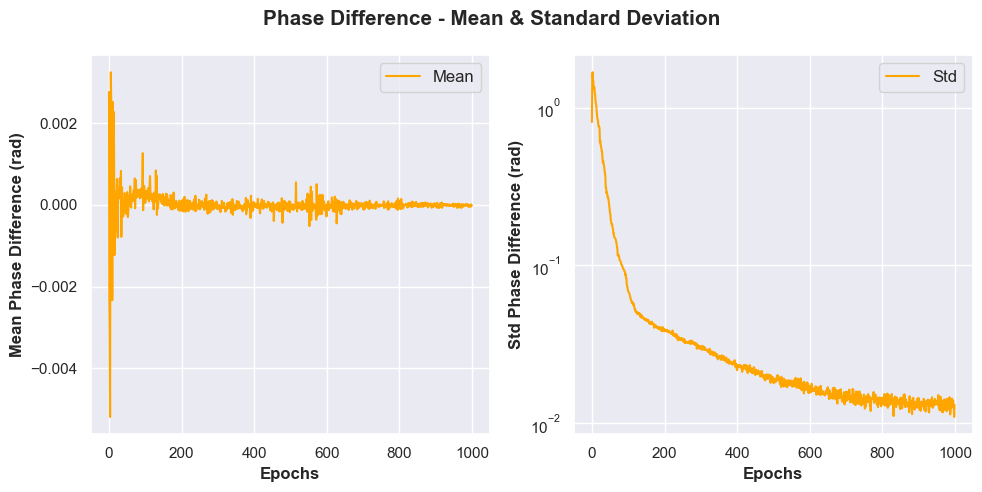

In [8]:
paths_curve = os.path.join(os.getcwd(), "experiments/exp_2025-11-13_08-55-14/curves")

# phase difference - mean & std
with open(os.path.join(paths_curve,"Train_PhaseDifference_Mean.json"), "r") as f:
    mean_phase_diff = json.load(f)
    mean_phase_diff = np.array(mean_phase_diff)

with open(os.path.join(paths_curve, "Train_PhaseDifference_St.deviation.json"), "r") as f:
    std_phase_diff = json.load(f)
    std_phase_diff = np.array(std_phase_diff)

plot_phase_subplot(paths_curve,  mean_phase_diff[:, -1], std_phase_diff[:, -1], 
                   yaxis_1="Mean Phase Difference (rad)", yaxis_2="Std Phase Difference (rad)",
                   label1="Mean", label2="Std", 
                   log_curve1=False, log_curve2=True, save_name="phase_mean_std.png",
                   title="Phase Difference - Mean & Standard Deviation")


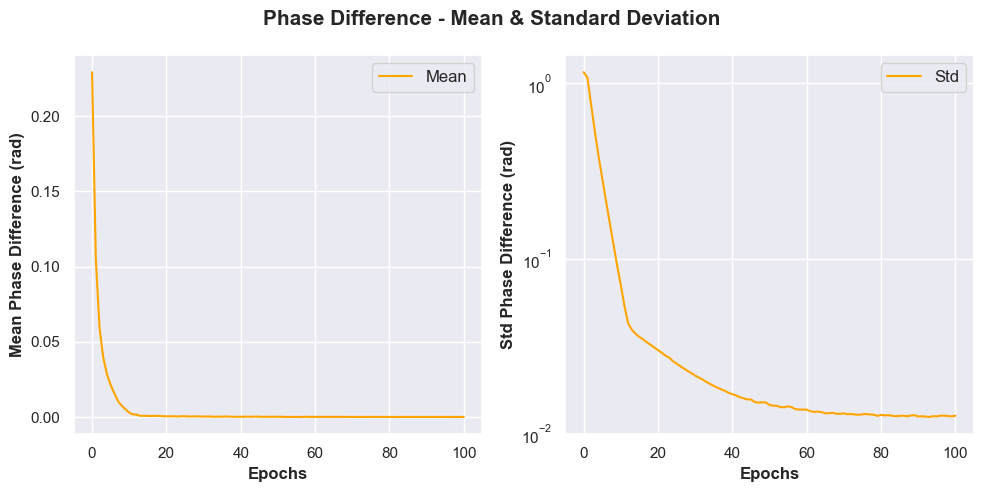

In [ ]:
paths_curve = os.path.join(os.getcwd(), "experiments/exp_2025-11-13_08-55-14/curves")

# phase difference - mean & std
with open(os.path.join(paths_curve,"Val_PhaseDifference_Mean.json"), "r") as f:
    mean_magnitude_diff = json.load(f)
    mean_magnitude_diff = np.array(mean_magnitude_diff)

with open(os.path.join(paths_curve, "Val_PhaseDifference_St.deviation.json"), "r") as f:
    std_phase_diff = json.load(f)
    std_phase_diff = np.array(std_phase_diff)

plot_phase_subplot(paths_curve,  mean_phase_diff[:, -1], std_phase_diff[:, -1], 
                   yaxis_1="Mean Phase Difference (rad)", yaxis_2="Std Phase Difference (rad)",
                   label1="Mean", label2="Std", 
                   log_curve1=False, log_curve2=True, save_name="phase_mean_std.png",
                   title="Phase Difference - Mean & Standard Deviation")


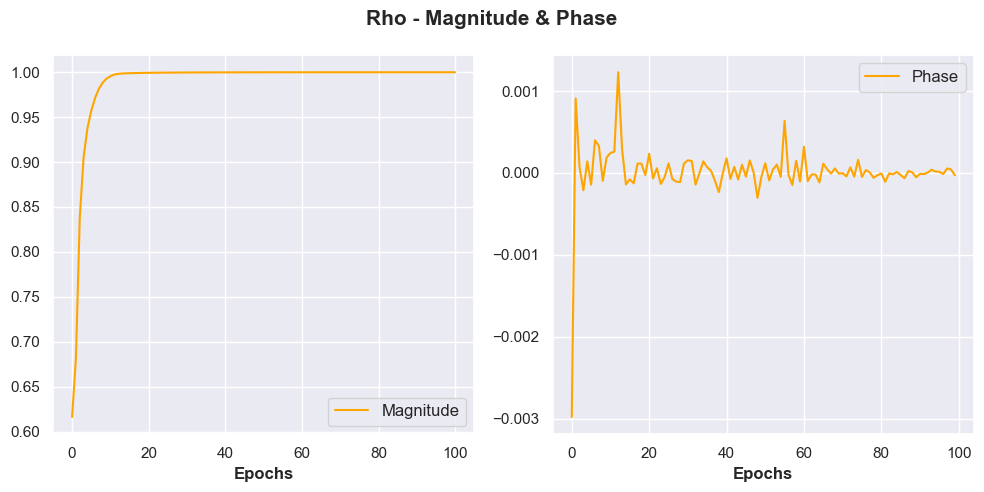

In [34]:
# rho - Magnitude & Phase
with open(os.path.join(paths_curve,"Val_MagnitudeDifference_Rho.json"), "r") as f:
    mean_phase_diff = json.load(f)
    mean_phase_diff = np.array(mean_phase_diff)

with open(os.path.join(paths_curve, "Val_PhaseDifference_Rho.json"), "r") as f:
    std_phase_diff = json.load(f)
    std_phase_diff = np.array(std_phase_diff)

std_phase_diff_ = std_phase_diff[:, -1][1:] 

plot_phase_subplot(paths_curve, mean_phase_diff[:, -1], std_phase_diff_, #std_phase_diff[:, -1], 
                   yaxis_1="", yaxis_2="",
                   label1="Magnitude", label2="Phase",
                   log_curve1=False, log_curve2=False, save_name="rho_magnitude_phase.png", 
                   title="Rho - Magnitude & Phase")